In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [17]:
# check versions
print("Pytorch version: {}".format(torch.__version__))
print("Numpy version: {}".format(np.__version__))

Pytorch version: 2.8.0+cu126
Numpy version: 2.0.2


In [18]:
# Load Iris Dataset
FILE_PATH = "/My Drive/"
MAIN_FILE_NAME = "iris_dataset.txt"
TRAIN_FILE_NAME = "iris_train_dataset.txt"
TEST_FILE_NAME = "iris_test_dataset.txt"
NUM_FEATRUE = 4
NUM_CLASS = 3
num_epoch = 200

In [19]:
#data = np.loadtxt(FILE_PATH + MAIN_FILE_NAME, delimiter=",")
data = np.loadtxt("/content/gdrive/My Drive/iris_dataset.txt", delimiter=",")
mean_data = np.mean((data[:,:NUM_FEATRUE]), axis = 0)
std_data = np.std((data[:,:NUM_FEATRUE]), axis = 0)

In [20]:
train_data = np.loadtxt("/content/gdrive/My Drive/iris_train_dataset.txt", delimiter=",")
test_data = np.loadtxt("/content/gdrive/My Drive/iris_test_dataset.txt", delimiter=",")

In [21]:
print("Mean of features: {}".format(mean_data))
print("Std of features: {}".format(std_data))

Mean of features: [5.84333333 3.054      3.75866667 1.19866667]
Std of features: [0.82530129 0.43214658 1.75852918 0.76061262]


In [22]:
# Standardize ( Pre-process ) train and test data
for j in range(NUM_FEATRUE):
  for i in range(train_data.shape[0]):
    train_data[i,j] = (train_data[i,j] - mean_data[j])/std_data[j]
  for i in range(test_data.shape[0]):
    test_data[i,j] = (test_data[i,j] - mean_data[j])/std_data[j]

In [23]:
train_data = torch.Tensor(train_data)
test_data = torch.Tensor(test_data)

In [24]:
device = torch.device('cuda:0')

In [25]:
D_in, H, D_out = NUM_FEATRUE, 8, 3
model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
    torch.nn.Softmax(dim=0)
)

In [26]:
loss_fn = torch.nn.MSELoss(reduction='mean')

In [27]:
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [32]:
idx = np.arange(train_data.size()[0])
print(idx)
avg_loss_list = list()
epoch_list = list()

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]


In [34]:
for epoch in range(num_epoch):
  total_loss = 0
  np.random.shuffle(idx)
  for id in idx:
    y_pred = model(train_data[id,:NUM_FEATRUE])
    y = train_data[id,NUM_FEATRUE:]
    loss = loss_fn(y_pred, y)
    total_loss += loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  avg_loss = total_loss/train_data.size()[0]
  avg_loss_list.append(avg_loss)
  epoch_list.append(epoch)

In [38]:
print(epoch_list)
print(avg_loss_list)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199]
[tensor(0.2522, grad_fn=<DivBackward0>), tensor(0.2496, grad_fn=<DivBackward0>), tensor(0.2469, grad_fn=<DivB

In [50]:
values = [t.item() for t in avg_loss_list]

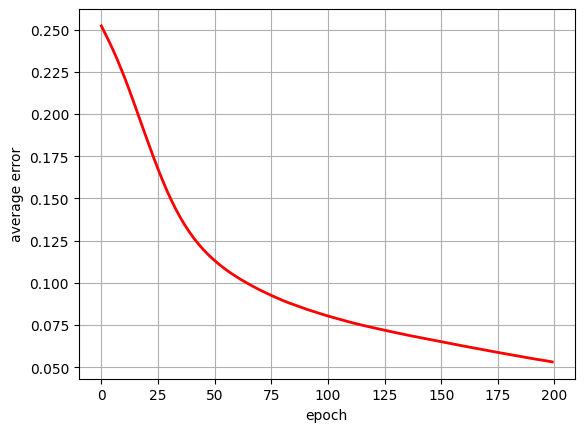

Confusion matrix:
 [[ 9.  0.  0.]
 [ 1. 10.  0.]
 [ 0.  0. 10.]]


In [51]:
plt.plot(epoch_list, values, 'r-', lw=2)
plt.xlabel("epoch")
plt.ylabel("average error")
plt.grid(True)
plt.show()

pred_class = list()
actual_class = list()
for i in range(test_data.shape[0]):
  y_pred_test = model(test_data[i, :NUM_FEATRUE])
  val_pred, indices_pred = torch.max(y_pred_test, 0)
  val_actual, indices_actual = torch.max(test_data[i,NUM_FEATRUE:], 0)
  pred_class.append(indices_pred)
  actual_class.append(indices_actual)

conf_mat = np.zeros((NUM_CLASS, NUM_CLASS))
for i,j in zip(pred_class, actual_class):
  conf_mat[i,j] += 1
print("Confusion matrix:\n", conf_mat)